# 实验 2：OODA 全链路时延与 20–100 机蜂群资源裁决

本 Notebook 解决旧版的两个关键缺口：

1. 旧 `t_OODA≈0.39 s` 只含软件处理，本实验显式加入传感器重访、航迹起始、多传感识别、通信、人工授权、武器-目标分配、效应器瞄准、效应到达和毁伤评估；
2. 旧 20 机场景用威胁数量直接代入 Sigmoid，固定得到约 0.182，却没有通道、循环、库存、成本或分层反馈。本实验改用容量约束的逐层蒙特卡洛裁决，并把资源扩展前沿推进到 100 机；
3. 多资源包不再被当成“零开销复制”。主口径加入跨包航迹同步、任务去冲突和指令编组时延，同时保留不计协调开销的理想并行上界。

全部时间和效能参数均为可查询的合成工程假设，等待台架/外场数据校准；不是机场现场实测或实装武器效能。

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
APP_DIR = PROJECT_ROOT / '03_源码' / 'streamlit_app'
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

OUTPUT_DIR = NOTEBOOK_DIR / '验证输出'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from utils.ooda_model import (
    CONFIG_PATH as OODA_CONFIG_PATH,
    compare_effectors,
    load_ooda_config,
    simulate_ooda_timing,
    timing_parameter_rows,
)
from utils.swarm_adjudication import (
    CONFIG_PATH as SWARM_CONFIG_PATH,
    evaluate_closed_loop_swarm,
    legacy_sigmoid_score,
    load_swarm_config,
    resource_capacity_rows,
    resource_scaling_study,
    stress_test_20_swarm,
)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('OODA 参数:', OODA_CONFIG_PATH)
print('蜂群资源参数:', SWARM_CONFIG_PATH)

OODA 参数: D:\Downloads\反无人机体系\cuas-ontology-demo-consolidated\03_源码\streamlit_app\data\ooda_timing_params.json
蜂群资源参数: D:\Downloads\反无人机体系\cuas-ontology-demo-consolidated\03_源码\streamlit_app\data\swarm_resources.json


## 1. OODA 口径与可查询参数表

- **授权前决策链**：Observe + Orient + Decide；
- **首个效应到达**：决策链 + 指令下行 + 提示/瞄准 + 效应传递；
- **完整闭环**：首个效应到达 + 毁伤/失效评估；
- 工程门槛：完整闭环 `< 5 s`，不是只约束软件推理时间。

每个分量使用三角分布 `Triangular(low, mode, high)`；目标规模通过公开的 `log2(N)` 系数放大关联、评估与分配负担。多资源包协调分量按 `(P-1)×[1+0.25×max(0,log2(N/20))]` 缩放，其中 `P` 为资源包数量。

In [2]:
timing_table = pd.DataFrame(timing_parameter_rows(
    effector_id='HPM',
    threat_count=20,
    authorization_mode='batch',
    degradation_profile='nominal',
))
timing_query = timing_table[[
    'id', 'phase', 'name_zh',
    'scaled_low_s', 'scaled_mode_s', 'scaled_high_s',
    'scale_factor', 'notes'
]].copy()
timing_query.to_csv(OUTPUT_DIR / 'ooda_timing_parameters_20_swarm.csv', index=False, encoding='utf-8-sig')
coordination_table = pd.DataFrame(timing_parameter_rows(
    effector_id='HPM',
    threat_count=100,
    authorization_mode='batch',
    degradation_profile='nominal',
    resource_package_count=6,
    coordination_mode='coordination_aware',
))
coordination_query = coordination_table.loc[
    coordination_table['id'] == 'multi_package_coordination',
    ['id', 'phase', 'name_zh', 'scaled_low_s', 'scaled_mode_s', 'scaled_high_s',
     'scale_factor', 'notes'],
].copy()
coordination_query.to_csv(
    OUTPUT_DIR / 'ooda_coordination_parameters_100_swarm_6_packages.csv',
    index=False,
    encoding='utf-8-sig',
)
print('20 机单包完整参数：')
display(timing_query)
print('100 机 / 6 包协调附加分量：')
coordination_query

20 机单包完整参数：


,id,phase,name_zh,scaled_low_s,scaled_mode_s,scaled_high_s,scale_factor,notes
0,sensor_revisit_confirmation,Observe,传感器重访与连续确认,0.140745,0.293219,0.645082,1.172877,雷达/RF 至少一次重访，形成可用初始告警
1,track_initiation,Observe,航迹起始与稳定化,0.100745,0.226677,0.503726,1.259316,多目标规模增加关联与稳定化负担
2,sensor_data_uplink,Observe,传感数据上行通信,0.016297,0.043458,0.108644,1.086439,传感节点至融合/C2 节点的数据传输与排队
3,multisensor_correlation_id,Orient,多传感关联与身份识别,0.134575,0.322981,0.740165,1.345754,雷达/RF/光电航迹关联、分类与置信度更新
4,semantic_threat_assessment,Orient,本体语义威胁评估,0.033644,0.094203,0.215321,1.345754,结合资产、轨迹、ROE 和能力约束生成威胁排序
5,c2_data_transport,Decide,C2 数据与告警通信,0.016297,0.054322,0.130373,1.086439,融合节点、指挥席和效应器控制节点之间的消息传输
6,weapon_target_allocation,Decide,资源约束武器-目标分配,0.060745,0.167049,0.425217,1.518631,显式考虑通道数、循环周期、弹药/能量与射界
7,human_authorization,Decide,人工授权与 ROE 核验,0.200000,0.550000,1.200000,1.000000,主场景按单批次授权；逐目标授权作为压力工况
8,exception_rework_queue,Decide,异常复核与排队附加时延,0.434575,1.086439,2.607453,1.086439,仅在 6% 标称仿真中触发，表示身份冲突、ROE 复核或链路重传；未触发时为 0
9,effector_command_downlink,Act,效应器指令下行通信,0.015648,0.046945,0.114754,1.043219,授权指令、目标指示和交战参数下发


100 机 / 6 包协调附加分量：


,id,phase,name_zh,scaled_low_s,scaled_mode_s,scaled_high_s,scale_factor,notes
13,multi_package_coordination,Decide,跨资源包同步、去冲突与指令编组,0.158048,0.474145,1.106337,7.90241,"每增加一个同构资源包增加一次协调负担，并按 max(0, log2(N/20)) 放大；数值..."


## 2. 不同效应器的完整闭环时延

In [3]:
effector_timing = pd.DataFrame(compare_effectors(
    threat_count=20,
    authorization_mode='batch',
    degradation_profile='nominal',
    n_runs=20_000,
    seed=20260812,
))
effector_timing

,effector_id,effector_name_zh,decision_mean_s,first_effect_mean_s,full_loop_mean_s,full_loop_p90_s,full_loop_p95_s,probability_under_5s
0,EW,定向电磁干扰,2.223753,2.880536,3.317717,3.835644,4.177347,0.98570
1,HPM,高功率微波,2.223753,2.727038,3.164220,3.670253,4.008999,0.98960
2,HEL,高能激光,2.223753,4.359504,4.796685,5.605681,5.924094,0.65635
3,Kinetic,动能拦截,2.223753,4.513188,4.950369,5.838771,6.159480,0.56095
4,Net,拦截网,2.223753,4.336325,4.773507,5.583701,5.907977,0.66960


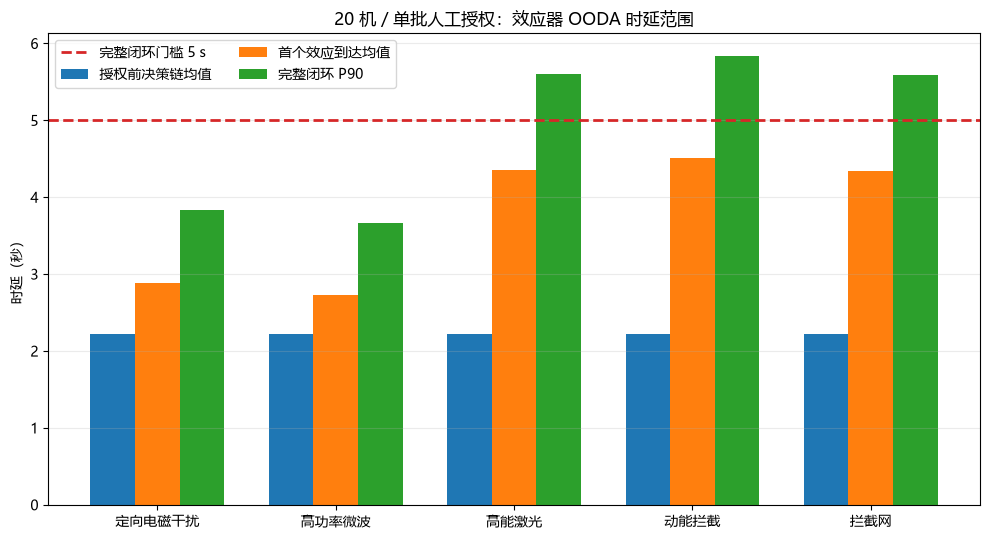

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(effector_timing))
width = 0.25
ax.bar(x - width, effector_timing['decision_mean_s'], width, label='授权前决策链均值')
ax.bar(x, effector_timing['first_effect_mean_s'], width, label='首个效应到达均值')
ax.bar(x + width, effector_timing['full_loop_p90_s'], width, label='完整闭环 P90')
ax.axhline(5.0, color='#D62728', ls='--', lw=2, label='完整闭环门槛 5 s')
ax.set_xticks(x, effector_timing['effector_name_zh'])
ax.set_ylabel('时延（秒）')
ax.set_title('20 机 / 单批人工授权：效应器 OODA 时延范围')
ax.grid(axis='y', alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig2_4_stage_lines.png', dpi=160, bbox_inches='tight')
plt.show()

In [5]:
hpm_timing = simulate_ooda_timing(
    effector_id='HPM',
    threat_count=20,
    authorization_mode='batch',
    degradation_profile='nominal',
    n_runs=20_000,
    seed=20260812,
)
phase_table = pd.DataFrame(hpm_timing.phase_rows)
print('授权前决策链:', hpm_timing.decision_summary)
print('首个效应到达:', hpm_timing.first_effect_summary)
print('完整闭环:', hpm_timing.full_loop_summary)
phase_table

授权前决策链: {'mean_s': 2.223752928486778, 'p50_s': 2.1578861069654396, 'p90_s': 2.6519515525079127, 'p95_s': 3.0125569975057185}
首个效应到达: {'mean_s': 2.727038494701279, 'p50_s': 2.6636027071721355, 'p90_s': 3.172079233677133, 'p95_s': 3.539064161998308}
完整闭环: {'mean_s': 3.1642199363435353, 'p50_s': 3.1031090024568484, 'p90_s': 3.670253343243984, 'p95_s': 4.00899934872366, 'probability_under_deadline': 0.9896}


,phase,mean_s,p50_s,p90_s,p95_s
0,Observe,0.692671,0.686542,0.872454,0.924851
1,Orient,0.511467,0.499332,0.698938,0.749194
2,Decide,1.019615,0.942019,1.341731,1.798396
3,Act,0.503286,0.498156,0.634945,0.671985
4,Feedback,0.437181,0.420450,0.641616,0.693886


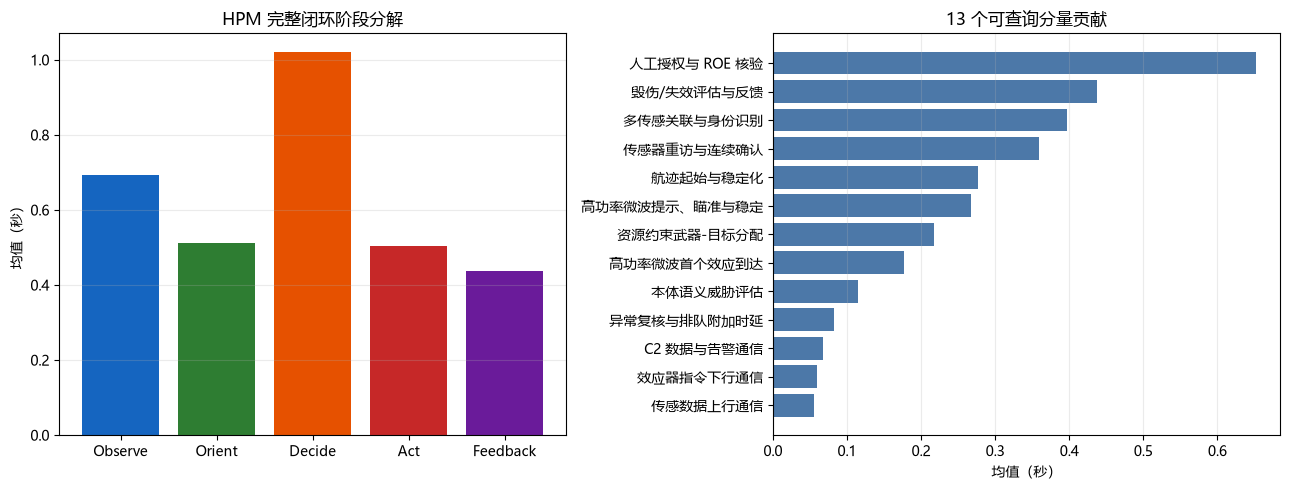

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(phase_table['phase'], phase_table['mean_s'], color=['#1565C0','#2E7D32','#E65100','#C62828','#6A1B9A'])
axes[0].set_ylabel('均值（秒）')
axes[0].set_title('HPM 完整闭环阶段分解')
axes[0].grid(axis='y', alpha=0.25)

component_means = pd.DataFrame([
    {
        'name_zh': row['name_zh'],
        'mean_s': float(hpm_timing.component_samples[row['id']].mean()),
    }
    for row in hpm_timing.component_rows
]).sort_values('mean_s')
axes[1].barh(component_means['name_zh'], component_means['mean_s'], color='#4C78A8')
axes[1].set_xlabel('均值（秒）')
axes[1].set_title(f'{len(component_means)} 个可查询分量贡献')
axes[1].grid(axis='x', alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig2_1_stage_decomp.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. 人工授权和链路退化压力工况

In [7]:
timing_stress_rows = []
for auth, degradation in [
    ('preauthorized', 'nominal'),
    ('batch', 'nominal'),
    ('per_target', 'nominal'),
    ('batch', 'contested'),
    ('batch', 'manual_fallback'),
]:
    result = simulate_ooda_timing(
        effector_id='HPM', threat_count=20,
        authorization_mode=auth, degradation_profile=degradation,
        n_runs=20_000, seed=20260812,
    )
    timing_stress_rows.append({
        '授权模式': auth,
        '链路工况': degradation,
        '完整闭环均值_s': result.full_loop_summary['mean_s'],
        '完整闭环P90_s': result.full_loop_summary['p90_s'],
        'P(闭环<5s)': result.full_loop_summary['probability_under_deadline'],
    })
timing_stress = pd.DataFrame(timing_stress_rows)
timing_stress

,授权模式,链路工况,完整闭环均值_s,完整闭环P90_s,P(闭环<5s)
0,preauthorized,nominal,2.740485,3.146421,0.99750
1,batch,nominal,3.164220,3.670253,0.98960
2,per_target,nominal,5.393720,6.771133,0.38540
3,batch,contested,3.915905,4.532340,0.95335
4,batch,manual_fallback,4.088205,4.743016,0.93500


## 4. 20 机蜂群：资源容量与使命成功定义

主场景的 `P_k` 不再是单目标平均杀伤概率，而定义为：

\[
P_k^{mission}=P\{K\ge \lceil0.8Nceil\ \land\ t_{full}<5s\}.
\]

对 `N=20`，要求在完整闭环截止时间内至少使 **16 架**威胁失效。资源表显式给出通道、循环、窗口、库存、每次作用目标数与成本。

In [8]:
capacity_table = pd.DataFrame(resource_capacity_rows())
capacity_table.to_csv(OUTPUT_DIR / 'swarm_resource_capacity.csv', index=False, encoding='utf-8-sig')
capacity_table

,effector_id,name_zh,engagement_type,base_single_target_pk,channels,cycle_time_s,allocated_window_s,inventory,resource_package_count,actions_per_package,available_actions,targets_per_action,max_target_engagements,cost_per_action,disabled,notes
0,EW,定向电磁干扰,area,0.25,1,1.20,1.2,1,1,1,1,20,20,0.2,False,单次扇区压制覆盖当前全部存活目标，存在目标抗干扰差异
1,HPM,高功率微波,group,0.62,1,0.75,1.6,4,1,2,2,6,12,0.8,False,两次群目标脉冲，每次最多覆盖 6 个当前存活目标
2,HEL,高能激光,precision,0.88,1,1.05,3.3,8,1,3,3,1,3,0.6,False,单通道精确补射，受跟踪可用性约束
3,Kinetic,动能拦截,precision,0.84,2,1.45,4.5,6,1,6,6,1,6,0.7,False,双通道、总弹药 6 发，用于穿透软杀伤层的剩余目标


## 5. 修复旧 20 机裁决：动态反馈分配 vs 同资源静态规则

- **动态反馈策略**：每个作用层结束后，根据仍存活目标重新分配下一层资源；
- **静态覆盖策略（无反馈）**：交战前按威胁优先级跨效应器协调覆盖，先给每个可跟踪目标一次非面杀伤机会，再冻结全部目标表；它不是故意浪费的弱基线，但层间不读取效果反馈，后续动作仍可能落在已失效目标上；
- 两者使用同一资源容量、成本参数、目标分布和随机种子；旧 Sigmoid 仅作为废弃公式诊断。

In [9]:
N_MAIN = 20_000
adaptive = evaluate_closed_loop_swarm(
    threat_count=20,
    policy='adaptive',
    degradation_profile='nominal',
    authorization_mode='batch',
    n_runs=N_MAIN,
    seed=20260813,
)
static = evaluate_closed_loop_swarm(
    threat_count=20,
    policy='static',
    degradation_profile='nominal',
    authorization_mode='batch',
    n_runs=N_MAIN,
    seed=20260813,
)
legacy_pk = legacy_sigmoid_score(20)

adaptive_successes = int(adaptive.joint_success_flags.sum())
adaptive_ci = proportion_confint(adaptive_successes, N_MAIN, alpha=0.05, method='wilson')
static_successes = int(static.joint_success_flags.sum())
static_ci = proportion_confint(static_successes, N_MAIN, alpha=0.05, method='wilson')

policy_comparison = pd.DataFrame([
    {
        '裁决': '旧威胁数 Sigmoid（废弃）',
        '闭环使命Pk': legacy_pk,
        '95%CI下界': np.nan,
        '95%CI上界': np.nan,
        '平均失效数': np.nan,
        '平均资源成本': np.nan,
    },
    {
        '裁决': '同资源静态覆盖表（无反馈）',
        '闭环使命Pk': static.closed_loop_mission_probability,
        '95%CI下界': static_ci[0],
        '95%CI上界': static_ci[1],
        '平均失效数': static.swarm.mean_neutralized,
        '平均资源成本': static.swarm.mean_resource_cost,
    },
    {
        '裁决': '容量约束动态反馈',
        '闭环使命Pk': adaptive.closed_loop_mission_probability,
        '95%CI下界': adaptive_ci[0],
        '95%CI上界': adaptive_ci[1],
        '平均失效数': adaptive.swarm.mean_neutralized,
        '平均资源成本': adaptive.swarm.mean_resource_cost,
    },
])
print(f'20 机主场景闭环使命 Pk = {adaptive.closed_loop_mission_probability:.4f}')
print(f'Wilson 95% CI = [{adaptive_ci[0]:.4f}, {adaptive_ci[1]:.4f}]')
policy_comparison

20 机主场景闭环使命 Pk = 0.7655
Wilson 95% CI = [0.7596, 0.7713]


,裁决,闭环使命Pk,95%CI下界,95%CI上界,平均失效数,平均资源成本
0,旧威胁数 Sigmoid（废弃）,0.182426,NaN,NaN,NaN,NaN
1,同资源静态覆盖表（无反馈）,0.300700,0.294384,0.307093,14.35415,7.80000
2,容量约束动态反馈,0.765500,0.759577,0.771321,17.30550,7.39446


In [10]:
usage_table = pd.DataFrame(adaptive.swarm.resource_usage_rows)
usage_table

,effector_id,name_zh,mean_actions,mean_neutralizations,mean_cost
0,EW,定向电磁干扰,1.0000,4.41300,0.20000
1,HPM,高功率微波,2.0000,6.55495,1.60000
2,HEL,高能激光,2.9919,2.32690,1.79514
3,Kinetic,动能拦截,5.4276,4.01065,3.79932


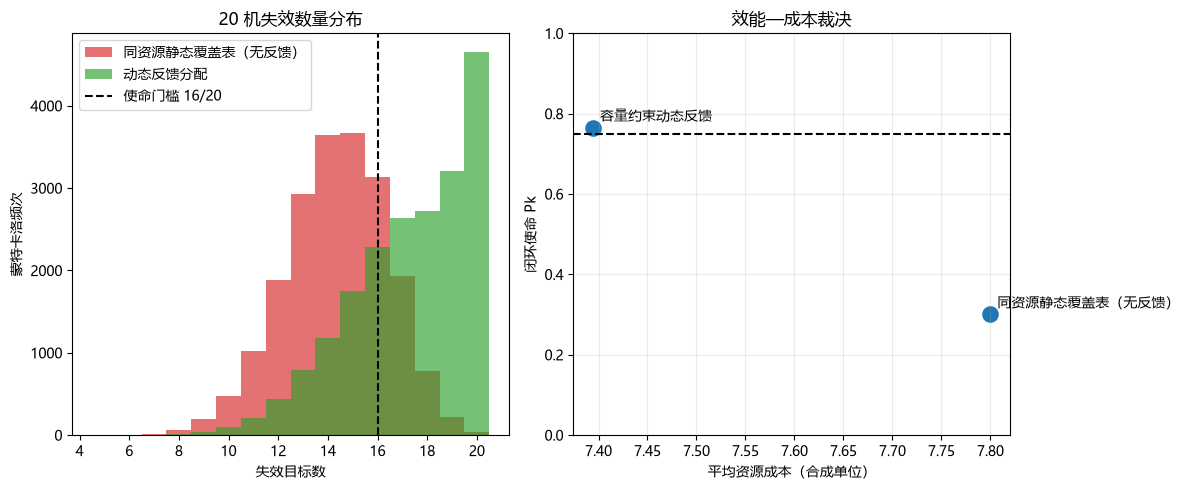

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bins = np.arange(4.5, 20.6, 1)
axes[0].hist(static.swarm.neutralized_counts, bins=bins, alpha=0.65, label='同资源静态覆盖表（无反馈）', color='#D62728')
axes[0].hist(adaptive.swarm.neutralized_counts, bins=bins, alpha=0.65, label='动态反馈分配', color='#2CA02C')
axes[0].axvline(16, color='black', ls='--', label='使命门槛 16/20')
axes[0].set_xlabel('失效目标数')
axes[0].set_ylabel('蒙特卡洛频次')
axes[0].set_title('20 机失效数量分布')
axes[0].legend()

plot_df = policy_comparison.dropna(subset=['平均资源成本'])
axes[1].scatter(plot_df['平均资源成本'], plot_df['闭环使命Pk'], s=120)
for _, row in plot_df.iterrows():
    axes[1].annotate(row['裁决'], (row['平均资源成本'], row['闭环使命Pk']), xytext=(5, 5), textcoords='offset points')
axes[1].axhline(0.75, color='black', ls='--', label='内部工程门槛 0.75')
axes[1].set_xlabel('平均资源成本（合成单位）')
axes[1].set_ylabel('闭环使命 Pk')
axes[1].set_ylim(0, 1)
axes[1].set_title('效能—成本裁决')
axes[1].grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig2_3_baseline_cmp.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. 退化工况与门槛敏感性

In [12]:
stress_table = pd.DataFrame(stress_test_20_swarm(n_runs=10_000, seed=20260813))
stress_table

,case,degradation_profile,authorization_mode,required_fraction,required_neutralizations,engagement_success_probability,ooda_under_5s_probability,closed_loop_mission_probability,mean_neutralized,mean_resource_cost
0,nominal_80pct,nominal,batch,0.8,16,0.7747,0.9911,0.7678,17.3081,7.39994
1,sensor_degraded,sensor_degraded,batch,0.8,16,0.5138,0.9911,0.5089,15.3740,6.76052
2,contested,contested,batch,0.8,16,0.1920,0.9584,0.1839,13.0179,5.78167
3,hpm_offline,hpm_offline,batch,0.8,16,0.0331,0.9869,0.0324,11.1894,6.19993
4,nominal_90pct,nominal,batch,0.9,18,0.5290,0.9911,0.5244,17.3081,7.39994
5,per_target_authorization,nominal,per_target,0.8,16,0.7747,0.3858,0.2983,17.3081,7.39994


## 7. 20–100 机容量前沿与协调感知资源增配

固定资源扫描不是为了声称系统可以无限扩展，而是比较动态反馈与静态规则在同一资源包下何时开始饱和。保留 25–100 机单包失败区间，用于标出扩容边界。

资源增配扫描 **20/25/30/40/50/60/75/100 机 × 1–6 个同构资源包**。每个资源包复制当前全部启用效应器的独立并行动作容量，不提高单次作用 Pk，也不缩短基础 OODA 分量。

- **协调感知主口径**：加入跨资源包同步、任务去冲突和指令编组时延；
- **理想并行上界**：不计上述附加时延，只用于分离“动作容量不足”和“协调时延超限”；
- 全部方案在同一威胁规模内使用共同随机数，同时报告资源包数量和平均行动成本，但不虚构采购价或全寿命周期成本。

In [13]:
scale_rows = []
scenario_names = {
    1: 'A_LSS_Solo', 5: 'B_Swarm_5', 20: 'C_Swarm_20',
    50: 'D_Swarm_50', 100: 'E_Swarm_100',
}
for count in [1, 5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100]:
    adaptive_scale = evaluate_closed_loop_swarm(
        threat_count=count,
        policy='adaptive',
        n_runs=3_000,
        seed=20260813,
    )
    static_scale = evaluate_closed_loop_swarm(
        threat_count=count,
        policy='static',
        n_runs=3_000,
        seed=20260813,
    )
    scale_rows.append({
        'scenario': scenario_names.get(count, f'Swarm_{count}'),
        'threat_count': count,
        'required_neutralizations': adaptive_scale.swarm.neutralizations_required,
        'adaptive_closed_loop_pk': adaptive_scale.closed_loop_mission_probability,
        'static_closed_loop_pk': static_scale.closed_loop_mission_probability,
        'adaptive_mean_neutralized': adaptive_scale.swarm.mean_neutralized,
        'adaptive_mean_cost': adaptive_scale.swarm.mean_resource_cost,
        'static_mean_cost': static_scale.swarm.mean_resource_cost,
    })
scale_table = pd.DataFrame(scale_rows)
passing_counts = scale_table.loc[scale_table['adaptive_closed_loop_pk'] >= 0.75, 'threat_count']
capacity_frontier_n = int(passing_counts.max()) if len(passing_counts) else 0
print(f'当前固定资源包的扫描达标前沿：N={capacity_frontier_n}')

RESOURCE_STUDY_RUNS = 3_000
swarm_config = load_swarm_config()
scaling_spec = swarm_config['resource_scaling_study']
resource_scaling_raw = resource_scaling_study(
    n_runs=RESOURCE_STUDY_RUNS,
    seed=20260813,
)
resource_scaling_rows = []
for row in resource_scaling_raw:
    resource_scaling_rows.append({
        'threat_count': int(row['threat_count']),
        'resource_package_count': int(row['resource_package_count']),
        'ideal_parallel_ooda_under_deadline_probability': float(
            row['ideal_parallel_ooda_under_deadline_probability']
        ),
        'coordination_aware_ooda_under_deadline_probability': float(
            row['coordination_aware_ooda_under_deadline_probability']
        ),
        'coordination_delay_mean_s': float(row['coordination_delay_mean_s']),
        'coordination_delay_p90_s': float(row['coordination_delay_p90_s']),
        'adaptive_engagement_success_probability': float(
            row['adaptive']['engagement_success_probability']
        ),
        'adaptive_closed_loop_pk': float(row['adaptive']['closed_loop_pk']),
        'adaptive_wilson_ci95_low': float(row['adaptive']['wilson_ci95_low']),
        'adaptive_wilson_ci95_high': float(row['adaptive']['wilson_ci95_high']),
        'ideal_parallel_adaptive_closed_loop_pk': float(
            row['adaptive']['ideal_parallel_closed_loop_pk']
        ),
        'adaptive_mean_neutralized': float(row['adaptive']['mean_neutralized']),
        'adaptive_mean_action_cost': float(row['adaptive']['mean_action_cost']),
        'static_engagement_success_probability': float(
            row['static']['engagement_success_probability']
        ),
        'static_closed_loop_pk': float(row['static']['closed_loop_pk']),
        'static_wilson_ci95_low': float(row['static']['wilson_ci95_low']),
        'static_wilson_ci95_high': float(row['static']['wilson_ci95_high']),
        'ideal_parallel_static_closed_loop_pk': float(
            row['static']['ideal_parallel_closed_loop_pk']
        ),
        'static_mean_neutralized': float(row['static']['mean_neutralized']),
        'static_mean_action_cost': float(row['static']['mean_action_cost']),
        'same_resource_pk_advantage': float(
            row['adaptive']['closed_loop_pk'] - row['static']['closed_loop_pk']
        ),
        'adaptive_coordination_pk_loss': float(
            row['adaptive']['ideal_parallel_closed_loop_pk']
            - row['adaptive']['closed_loop_pk']
        ),
    })
resource_scaling_table = pd.DataFrame(resource_scaling_rows)
resource_scaling_table.to_csv(
    OUTPUT_DIR / 'swarm_resource_scaling_grid.csv',
    index=False,
    encoding='utf-8-sig',
)

RESOURCE_THRESHOLD = float(scaling_spec['success_threshold'])
HIGH_RELIABILITY_THRESHOLD = float(scaling_spec['high_reliability_threshold'])
MAX_RESOURCE_PACKAGES = max(int(item) for item in scaling_spec['package_counts'])

def minimum_packages_for_threshold(threshold):
    result_rows = []
    for threat_count, group in resource_scaling_table.groupby('threat_count', sort=True):
        ordered = group.sort_values('resource_package_count')
        adaptive_candidates = ordered.loc[
            ordered['adaptive_closed_loop_pk'] >= threshold
        ]
        static_candidates = ordered.loc[
            ordered['static_closed_loop_pk'] >= threshold
        ]
        adaptive_min = (
            int(adaptive_candidates.iloc[0]['resource_package_count'])
            if len(adaptive_candidates) else None
        )
        static_min = (
            int(static_candidates.iloc[0]['resource_package_count'])
            if len(static_candidates) else None
        )
        selected = (
            ordered.loc[ordered['resource_package_count'] == adaptive_min].iloc[0]
            if adaptive_min is not None else None
        )
        best = ordered.sort_values(
            ['adaptive_closed_loop_pk', 'resource_package_count'],
            ascending=[False, True],
        ).iloc[0]
        result_rows.append({
            'threshold': float(threshold),
            'threat_count': int(threat_count),
            'adaptive_minimum_resource_packages': adaptive_min,
            'static_minimum_resource_packages': static_min,
            'adaptive_pk_at_minimum': (
                float(selected['adaptive_closed_loop_pk']) if selected is not None else None
            ),
            'adaptive_wilson_ci95_low_at_minimum': (
                float(selected['adaptive_wilson_ci95_low']) if selected is not None else None
            ),
            'static_pk_at_same_packages': (
                float(selected['static_closed_loop_pk']) if selected is not None else None
            ),
            'same_package_pk_advantage': (
                float(selected['same_resource_pk_advantage']) if selected is not None else None
            ),
            'adaptive_mean_action_cost_at_minimum': (
                float(selected['adaptive_mean_action_cost']) if selected is not None else None
            ),
            'static_mean_action_cost_at_same_packages': (
                float(selected['static_mean_action_cost']) if selected is not None else None
            ),
            'best_available_adaptive_pk': float(best['adaptive_closed_loop_pk']),
            'best_available_resource_packages': int(best['resource_package_count']),
        })
    return result_rows

resource_scaling_minimum = minimum_packages_for_threshold(RESOURCE_THRESHOLD)
high_reliability_minimum = minimum_packages_for_threshold(HIGH_RELIABILITY_THRESHOLD)
minimum_package_table = pd.DataFrame(resource_scaling_minimum)
minimum_package_table.to_csv(
    OUTPUT_DIR / 'swarm_resource_scaling_minimum.csv',
    index=False,
    encoding='utf-8-sig',
)
threshold_package_table = pd.DataFrame(
    resource_scaling_minimum + high_reliability_minimum
)
threshold_package_table.to_csv(
    OUTPUT_DIR / 'swarm_resource_scaling_thresholds.csv',
    index=False,
    encoding='utf-8-sig',
)

print('固定资源规模扫描：')
display(scale_table)
print('达到点估计 Pk≥0.75 的最少资源包：')
display(minimum_package_table)
print('达到点估计 Pk≥0.95 的最少资源包（空值表示 1–6 包内未达到）：')
pd.DataFrame(high_reliability_minimum)

当前固定资源包的扫描达标前沿：N=20


固定资源规模扫描：


,scenario,threat_count,required_neutralizations,adaptive_closed_loop_pk,static_closed_loop_pk,adaptive_mean_neutralized,adaptive_mean_cost,static_mean_cost
0,A_LSS_Solo,1,1,0.996333,0.996333,0.997667,1.244167,7.8
1,B_Swarm_5,5,4,0.992667,0.871000,4.978333,2.337233,7.8
2,Swarm_10,10,8,0.989667,0.383667,9.920667,3.464533,7.8
3,Swarm_15,15,12,0.953000,0.306333,14.403667,5.845000,7.8
4,C_Swarm_20,20,16,0.768333,0.300667,17.356333,7.425333,7.8
5,Swarm_25,25,20,0.290333,0.010000,17.833667,7.788100,7.8
6,Swarm_30,30,24,0.033667,0.000000,17.877000,7.800000,7.8
7,Swarm_40,40,32,0.000000,0.000000,17.728333,7.800000,7.8
8,D_Swarm_50,50,40,0.000000,0.000000,17.798333,7.800000,7.8
9,Swarm_60,60,48,0.000000,0.000000,17.771667,7.800000,7.8


达到点估计 Pk≥0.75 的最少资源包：


,threshold,threat_count,adaptive_minimum_resource_packages,static_minimum_resource_packages,adaptive_pk_at_minimum,adaptive_wilson_ci95_low_at_minimum,static_pk_at_same_packages,same_package_pk_advantage,adaptive_mean_action_cost_at_minimum,static_mean_action_cost_at_same_packages,best_available_adaptive_pk,best_available_resource_packages
0,0.75,20,1,2.0,0.759333,0.743711,0.299667,0.459667,7.394100,7.8,0.982000,2
1,0.75,25,2,4.0,0.980333,0.974716,0.530333,0.450000,6.682033,15.6,0.980333,2
2,0.75,30,2,NaN,0.976667,0.970624,0.248667,0.728000,10.213367,15.6,0.977000,3
3,0.75,40,2,NaN,0.801333,0.786674,0.135333,0.666000,15.203833,15.6,0.974333,3
4,0.75,50,3,NaN,0.962667,0.955270,0.122333,0.840333,19.094067,23.4,0.967333,4
5,0.75,60,3,NaN,0.811333,0.796938,0.061667,0.749667,22.976033,23.4,0.966000,4
6,0.75,75,4,NaN,0.915333,0.904833,0.031000,0.884333,29.827533,31.2,0.962333,5
7,0.75,100,5,NaN,0.847000,0.833675,0.013667,0.833333,38.623400,39.0,0.952333,6


达到点估计 Pk≥0.95 的最少资源包（空值表示 1–6 包内未达到）：


,threshold,threat_count,adaptive_minimum_resource_packages,static_minimum_resource_packages,adaptive_pk_at_minimum,adaptive_wilson_ci95_low_at_minimum,static_pk_at_same_packages,same_package_pk_advantage,adaptive_mean_action_cost_at_minimum,static_mean_action_cost_at_same_packages,best_available_adaptive_pk,best_available_resource_packages
0,0.95,20,2,5.0,0.982000,0.976589,0.774333,0.207667,4.746267,15.6,0.982000,2
1,0.95,25,2,NaN,0.980333,0.974716,0.530333,0.450000,6.682033,15.6,0.980333,2
2,0.95,30,2,NaN,0.976667,0.970624,0.248667,0.728000,10.213367,15.6,0.977000,3
3,0.95,40,3,NaN,0.974333,0.968039,0.303000,0.671333,11.283300,23.4,0.974333,3
4,0.95,50,3,NaN,0.962667,0.955270,0.122333,0.840333,19.094067,23.4,0.967333,4
5,0.95,60,4,NaN,0.966000,0.958896,0.118000,0.848000,20.437700,31.2,0.966000,4
6,0.95,75,5,NaN,0.962333,0.954908,0.046333,0.916000,25.686433,39.0,0.962333,5
7,0.95,100,6,NaN,0.952333,0.944114,0.021000,0.931333,38.757533,46.8,0.952333,6


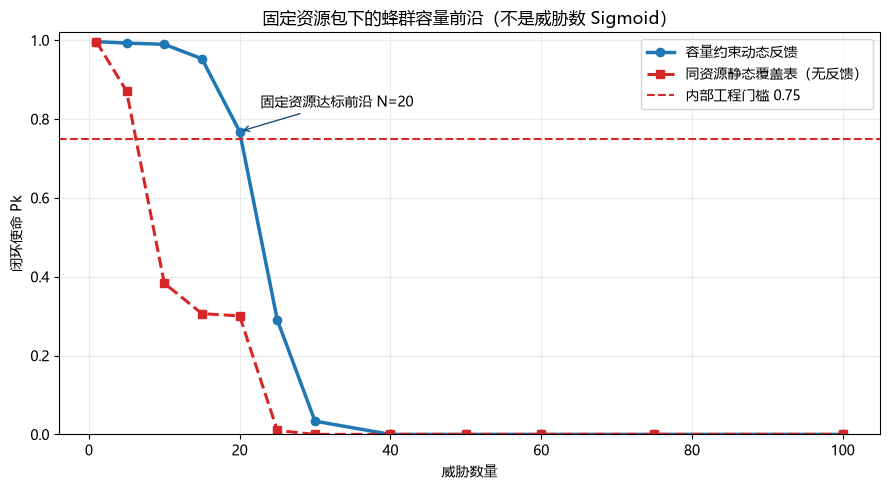

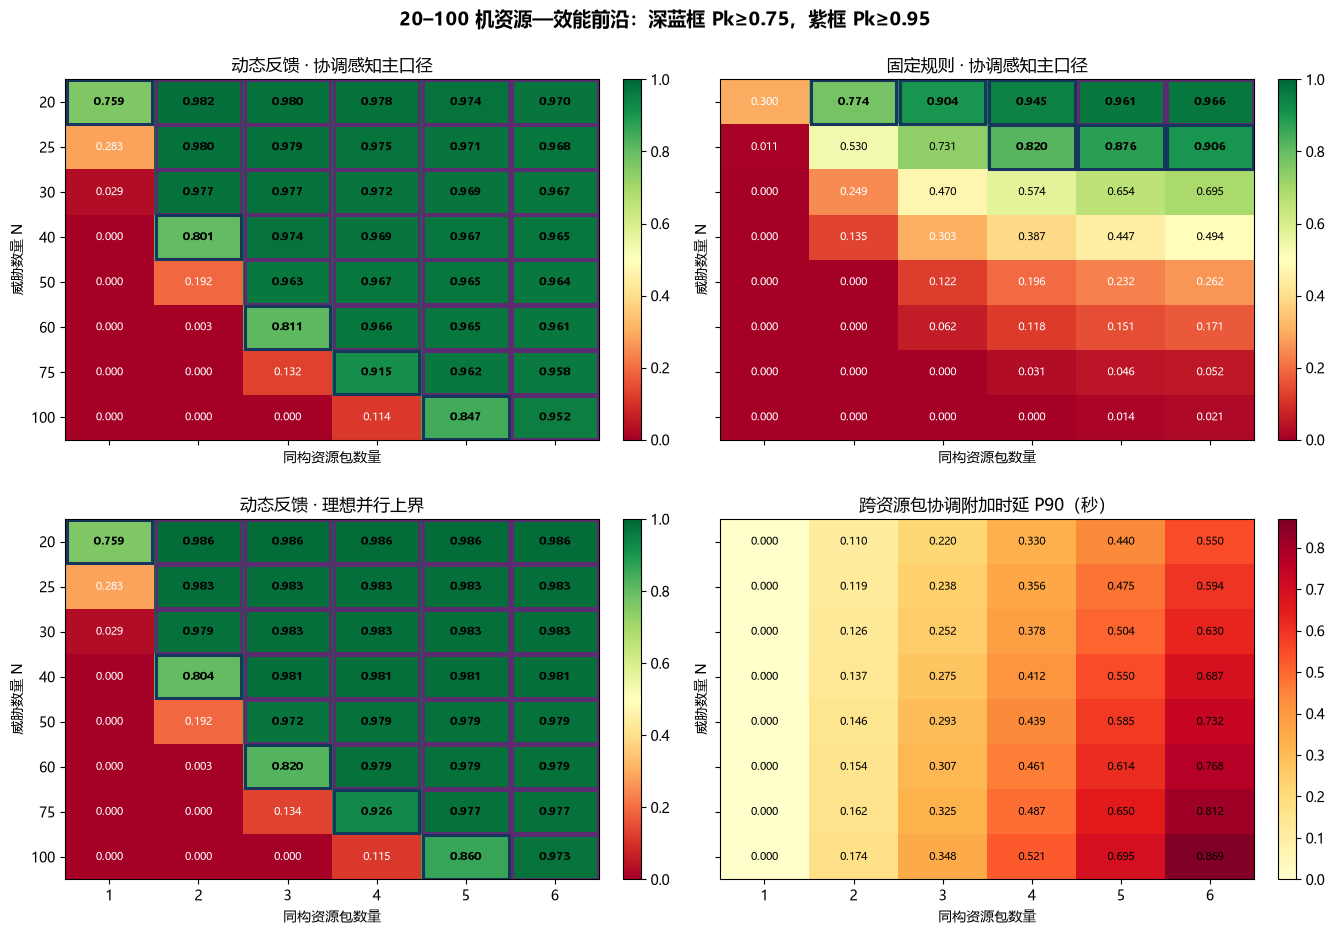

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(scale_table['threat_count'], scale_table['adaptive_closed_loop_pk'], 'o-', lw=2.5, color='#1F77B4', label='容量约束动态反馈')
ax.plot(scale_table['threat_count'], scale_table['static_closed_loop_pk'], 's--', lw=2.2, color='#D62728', label='同资源静态覆盖表（无反馈）')
ax.axhline(0.75, color='#D62728', ls='--', label='内部工程门槛 0.75')
frontier_row = scale_table.loc[scale_table['threat_count'] == capacity_frontier_n].iloc[0]
ax.annotate(
    f'固定资源达标前沿 N={capacity_frontier_n}',
    (frontier_row['threat_count'], frontier_row['adaptive_closed_loop_pk']),
    xytext=(15, 18), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#1F4E79'),
)
ax.set_xlabel('威胁数量')
ax.set_ylabel('闭环使命 Pk')
ax.set_ylim(0, 1.02)
ax.set_title('固定资源包下的蜂群容量前沿（不是威胁数 Sigmoid）')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig2_2_pk_vs_scale.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
panel_specs = [
    ('adaptive_closed_loop_pk', '动态反馈 · 协调感知主口径', 'RdYlGn', 0.0, 1.0, True),
    ('static_closed_loop_pk', '固定规则 · 协调感知主口径', 'RdYlGn', 0.0, 1.0, True),
    ('ideal_parallel_adaptive_closed_loop_pk', '动态反馈 · 理想并行上界', 'RdYlGn', 0.0, 1.0, True),
    (
        'coordination_delay_p90_s',
        '跨资源包协调附加时延 P90（秒）',
        'YlOrRd',
        0.0,
        float(resource_scaling_table['coordination_delay_p90_s'].max()),
        False,
    ),
]
for ax, (value_column, title, cmap, vmin, vmax, is_probability) in zip(
    axes.flat, panel_specs
):
    matrix = resource_scaling_table.pivot(
        index='threat_count',
        columns='resource_package_count',
        values=value_column,
    ).sort_index()
    image = ax.imshow(
        matrix.values,
        vmin=vmin,
        vmax=max(vmax, 1e-9),
        cmap=cmap,
        aspect='auto',
    )
    ax.set_xticks(range(len(matrix.columns)), labels=[str(item) for item in matrix.columns])
    ax.set_yticks(range(len(matrix.index)), labels=[str(item) for item in matrix.index])
    ax.set_xlabel('同构资源包数量')
    ax.set_ylabel('威胁数量 N')
    ax.set_title(title)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = float(matrix.iloc[row_index, column_index])
            ax.text(
                column_index,
                row_index,
                f'{value:.3f}',
                ha='center',
                va='center',
                color='white' if (is_probability and value < 0.35) else 'black',
                fontsize=8,
                fontweight=(
                    'bold' if is_probability and value >= RESOURCE_THRESHOLD else 'normal'
                ),
            )
            if is_probability and value >= RESOURCE_THRESHOLD:
                ax.add_patch(Rectangle(
                    (column_index - 0.48, row_index - 0.48),
                    0.96,
                    0.96,
                    fill=False,
                    edgecolor=(
                        '#5B2C6F' if value >= HIGH_RELIABILITY_THRESHOLD else '#17365D'
                    ),
                    linewidth=2.2,
                ))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(
    '20–100 机资源—效能前沿：深蓝框 Pk≥0.75，紫框 Pk≥0.95',
    fontsize=14,
    fontweight='bold',
)
fig.subplots_adjust(top=0.91, hspace=0.22, wspace=0.12)
fig.savefig(OUTPUT_DIR / 'fig2_5_resource_scaling.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. 自动验收与机器可读指标

In [15]:
checks = {
    'hpm_nominal_full_loop_p90_lt_5s': bool(hpm_timing.full_loop_summary['p90_s'] < 5.0),
    'hpm_nominal_probability_under_5s_ge_0_90': bool(hpm_timing.full_loop_summary['probability_under_deadline'] >= 0.90),
    '20_swarm_closed_loop_pk_ge_0_75': bool(adaptive.closed_loop_mission_probability >= 0.75),
    '20_swarm_wilson_lower_ge_0_75': bool(adaptive_ci[0] >= 0.75),
    'adaptive_cost_not_above_static': bool(adaptive.swarm.mean_resource_cost <= static.swarm.mean_resource_cost),
    'resource_capacity_explicit': bool(len(capacity_table) >= 4 and capacity_table['available_actions'].sum() > 0),
    'resource_scaling_all_threats_restored_within_six_packages': bool(
        all(item['adaptive_minimum_resource_packages'] is not None for item in resource_scaling_minimum)
    ),
    'resource_scaling_grid_reaches_100_threats_and_six_packages': bool(
        resource_scaling_table['threat_count'].max() == 100
        and resource_scaling_table['resource_package_count'].max() == 6
        and len(resource_scaling_table) == 48
    ),
    'resource_scaling_adaptive_not_below_static': bool(
        (resource_scaling_table['same_resource_pk_advantage'] >= -1e-12).all()
    ),
    'resource_scaling_engagement_monotonic_by_package': bool(all(
        np.all(np.diff(group.sort_values('resource_package_count')['adaptive_engagement_success_probability']) >= -1e-12)
        and np.all(np.diff(group.sort_values('resource_package_count')['static_engagement_success_probability']) >= -1e-12)
        for _, group in resource_scaling_table.groupby('threat_count')
    )),
    'coordination_aware_ooda_not_above_ideal_parallel': bool(
        (
            resource_scaling_table['coordination_aware_ooda_under_deadline_probability']
            <= resource_scaling_table['ideal_parallel_ooda_under_deadline_probability'] + 1e-12
        ).all()
    ),
    'coordination_delay_zero_for_one_package_positive_for_multiple': bool(
        (
            resource_scaling_table.loc[
                resource_scaling_table['resource_package_count'] == 1,
                'coordination_delay_p90_s',
            ] == 0.0
        ).all()
        and (
            resource_scaling_table.loc[
                resource_scaling_table['resource_package_count'] > 1,
                'coordination_delay_p90_s',
            ] > 0.0
        ).all()
    ),
    'high_reliability_frontier_reported_for_every_threat_count': bool(
        len(high_reliability_minimum) == len(scaling_spec['threat_counts'])
    ),
}
assert all(checks.values()), checks

scenario_summary = {
    row['scenario']: {
        'threat_count': int(row['threat_count']),
        'required_neutralizations': int(row['required_neutralizations']),
        'adaptive_closed_loop_mission_probability': float(row['adaptive_closed_loop_pk']),
        'static_closed_loop_mission_probability': float(row['static_closed_loop_pk']),
        'adaptive_mean_neutralized': float(row['adaptive_mean_neutralized']),
        'adaptive_mean_resource_cost': float(row['adaptive_mean_cost']),
        'static_mean_resource_cost': float(row['static_mean_cost']),
    }
    for _, row in scale_table.iterrows()
}

metrics_payload = {
    'schema_version': 2,
    'scope': 'synthetic_full_chain_ooda_and_capacity_constrained_swarm',
    'not_field_test': True,
    'time_unit': 'seconds',
    'random_seeds': {'ooda': 20260812, 'swarm': 20260813},
    'monte_carlo_main': N_MAIN,
    'ooda_parameter_file': str(OODA_CONFIG_PATH.relative_to(PROJECT_ROOT)),
    'swarm_resource_file': str(SWARM_CONFIG_PATH.relative_to(PROJECT_ROOT)),
    'ooda_effector_comparison': effector_timing.to_dict(orient='records'),
    'hpm_20_swarm_timing': {
        'decision_loop': hpm_timing.decision_summary,
        'time_to_first_effect': hpm_timing.first_effect_summary,
        'full_closed_loop': hpm_timing.full_loop_summary,
    },
    'legacy_20_swarm_sigmoid_score_deprecated': legacy_pk,
    'primary_20_swarm': {
        'mission_definition': 'neutralized >= 16 of 20 AND full_closed_loop < 5 s',
        'adaptive_engagement_success_probability': adaptive.swarm.mission_success_probability,
        'ooda_under_5s_probability': adaptive.ooda_probability_under_deadline,
        'closed_loop_mission_probability': adaptive.closed_loop_mission_probability,
        'closed_loop_wilson_ci95': [float(adaptive_ci[0]), float(adaptive_ci[1])],
        'mean_neutralized': adaptive.swarm.mean_neutralized,
        'p10_neutralized': adaptive.swarm.p10_neutralized,
        'mean_resource_cost': adaptive.swarm.mean_resource_cost,
        'static_closed_loop_mission_probability': static.closed_loop_mission_probability,
        'static_mean_resource_cost': static.swarm.mean_resource_cost,
    },
    'resource_capacity': capacity_table.to_dict(orient='records'),
    'adaptive_resource_usage': usage_table.to_dict(orient='records'),
    'stress_tests': stress_table.to_dict(orient='records'),
    'capacity_frontier_threat_count_at_pk_0_75': capacity_frontier_n,
    'scenario_summary': scenario_summary,
    'resource_scaling_study': {
        'monte_carlo_runs_per_cell': RESOURCE_STUDY_RUNS,
        'success_threshold': RESOURCE_THRESHOLD,
        'high_reliability_threshold': HIGH_RELIABILITY_THRESHOLD,
        'threat_counts': [int(item) for item in scaling_spec['threat_counts']],
        'package_counts': [int(item) for item in scaling_spec['package_counts']],
        'package_definition': scaling_spec['package_definition'],
        'primary_timing_mode': scaling_spec['primary_timing_mode'],
        'upper_bound_timing_mode': scaling_spec['upper_bound_timing_mode'],
        'coordination_assumption': scaling_spec['coordination_assumption'],
        'cost_reporting': scaling_spec['cost_reporting'],
        'common_random_numbers_within_threat_count': True,
        'grid': resource_scaling_table.to_dict(orient='records'),
        'minimum_packages': resource_scaling_minimum,
        'high_reliability_minimum_packages': high_reliability_minimum,
    },
    'checks': checks,
}
metrics_path = OUTPUT_DIR / 'metrics_notebook_02.json'
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print(json.dumps(checks, ensure_ascii=False, indent=2))
print('机器可读指标:', metrics_path)

{
  "hpm_nominal_full_loop_p90_lt_5s": true,
  "hpm_nominal_probability_under_5s_ge_0_90": true,
  "20_swarm_closed_loop_pk_ge_0_75": true,
  "20_swarm_wilson_lower_ge_0_75": true,
  "adaptive_cost_not_above_static": true,
  "resource_capacity_explicit": true,
  "resource_scaling_all_threats_restored_within_six_packages": true,
  "resource_scaling_grid_reaches_100_threats_and_six_packages": true,
  "resource_scaling_adaptive_not_below_static": true,
  "resource_scaling_engagement_monotonic_by_package": true,
  "coordination_aware_ooda_not_above_ideal_parallel": true,
  "coordination_delay_zero_for_one_package_positive_for_multiple": true,
  "high_reliability_frontier_reported_for_every_threat_count": true
}
机器可读指标: D:\Downloads\反无人机体系\cuas-ontology-demo-consolidated\05_Notebook与数据\验证输出\metrics_notebook_02.json


## 9. 结论与引用边界

1. OODA 已从软件处理链扩展为传感—通信—人工授权—分配—瞄准—效应到达—毁伤评估的全链路，并公开参数表；
2. 20 机不再因威胁数量直接套 Sigmoid 而失效，主场景由显式资源容量、动态反馈和完整闭环截止条件共同裁决；
3. 达标只适用于当前合成资源包和标称工况。HPM 离线、对抗链路、逐目标授权或 90% 更严门槛会显著降低结果，模型保留这些负面结论；
4. 在“同构并行资源包、共享融合航迹与批量授权”的合成假设下，资源增配实验给出 20–100 机分别达到 Pk≥0.75 与 Pk≥0.95 所需的最少资源包；协调感知主口径显式扣除了跨包同步、去冲突与指令编组时延，理想并行结果只作为容量上界；
5. 不能把本 Notebook 的秒数、Pk、资源包数量或成本单位表述为机场现场实测、采购报价或实装武器效能。